<a href="https://colab.research.google.com/github/biglalo104/Projects/blob/main/A%20MultiCriteria%20Decision%20Framework%20for%20Aligning%20Enterprise%20Cloud%20Migration%20Projects%20with%20Corporate%20Green%20Computing%20and%20Sustainability%20Strategies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print("Step 1:Data Intergration & Loading..")

# >>> SWAP IN REAL DATA HERE <<<
# workload_df = pd.read_csv('alibaba_cluster_trace.csv')
# carbon_df = pd.read_csv('co2_signal_history.csv')
# pricing_df = pd.read_csv('aws_pricing.csv')
# df = pd.merge_asof(workload_df.sort_values('timestamp'), carbon_df.sort_values('timestamp'), on='timestamp')

# For immediate execution, we generate 720 hours (1 month) of realistic integrated data:

hours = pd.date_range(start="2024-01-01",periods=720,freq="H")
df=pd.DataFrame({"timestamp":hours})
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"]=df["timestamp"].dt.dayofweek

Step 1:Data Intergration & Loading..


In [8]:
#Stimulate Workload Demand(Peaks at 10 AM and 2PM)
df["base_demand"] = 500+300*np.sin((df["hour"]-6)*np.pi/12)+np.random.normal(0,30,720)
df["base_demand"]=np.clip(df["base_demand"],100,1000)#CPU units

#Simulate Grid Intensity(gCO2e/kWh)-Drops during day(solar) and night (wind)
df["solar_factor"]=np.maximum(0,np.sin((df["hour"]-6)*np.pi/12))
df["wind_factor"]=0.3+0.2*np.sin((df["hour"]-2)*np.pi/12)
df["carbon_intensity"]=450-250*df["solar_factor"]-150*df["wind_factor"]+np.random.normal(0,20,720)
df["carbon_intensity"]=np.clip(df["carbon_intensity"],50,500)


#Simulate Pricing($per CPU hour)
df["price"]=0.05+0.02*(df["carbon_intensity"]/500)#Green regions cost slightly more


print("Step 2:Training ML Model for carbon intensity Foecasting")
X=df[["hour","day_of_week","solar_factor","wind_factor"]]
y=df["carbon_intensity"]

#Train Gradient Boosting(Proxy for XGBoost/RandomForest)
model=GradientBoostingRegressor(n_estimators=50,random_state=42)
X_train,X_test,y_train,y_test=X.iloc[:600],X.iloc[600:],y.iloc[:600],y.iloc[600:]
model.fit(X_train,y_train)
preds=model.predict(X_test)
mae=mean_absolute_error(y_test,preds)
print(f"ML Model traind.Mean Absolute Error(MAE):{mae:.2f}gCO2e/kWh")

Step 2:Training ML Model for carbon intensity Foecasting
ML Model traind.Mean Absolute Error(MAE):16.29gCO2e/kWh


In [12]:
from os import PRIO_PROCESS
#Add predictions to main dataframe for optimization
df["predicted_carbon"]=model.predict(X)

print("Step 3:Simulating Cloud Allocation Strategies")
#Helper functions for empirical quantification
def calc_carbon(demand,carbon_intensity,pue=1.2):
  power_kw=demand*0.005#0.005 kW per CPU unit
  return(power_kw*pue*carbon_intensity/1000)#Convert to kg CO2e

def calc_cost(demand,price):
  return demand * price

#Strategy A:Baseline (Run immediately in standard region)
df["cost_A"]=calc_cost(df["base_demand"],df["price"])
df["carbon_A"]= calc_carbon(df["base_demand"],df["carbon_intensity"])
df["latency_A"]=50 # MS
df["sla_A"]=99.0#%

#Strategy B:Cost-Optimized(Run in the cheapest region,higher carbon baseline)
df["cost_B"]= calc_cost(df["base_demand"],df["price"]*0.8)#20% Cheaper region
df["carbon_B"]=calc_carbon(df["base_demand"],df["carbon_intensity"]*1.3)#30% dirtier grid
df["latency_B"]=80
df["sla_B"]=97.5

#Strategy C:Carbon-Aware(Shift workload to lowest actual carbon hours)
shift_mask=df["carbon_intensity"]<df["carbon_intensity"].quantile(0.3)
df["shifted_demand_C"]=np.where(shift_mask,df["base_demand"]*1.3,df["base_demand"]*0.7)
df["cost_C"]=calc_cost(df["shifted_demand_C"],df["price"]*1.1)
df["carbon_C"]=calc_carbon(df["shifted_demand_C"],df["carbon_intensity"])
df["latency_C"]=65
df["sla_C"]=98.5

#Strategy D:ML-Optimized(Use ML predictions to optimize cost/carbon tradeoff)
opt_mask=(df["predicted_carbon"]<df["predicted_carbon"].quantile(0.4))&(df["price"]<df["price"].quantile(0.6))

df["shifted_demand_D"]=np.where(opt_mask,df["base_demand"]*1.2,df["base_demand"]*0.8)
df["carbon_D"]=calc_carbon(df["shifted_demand_D"],df["carbon_intensity"])
df["latency_D"]=55
df["sla_D"]=99.2
df["cost_D"]=calc_cost(df["shifted_demand_D"], df["price"]) # This line was missing

print("\n Step 4:Aggregating Raw Performance Metrics...")
metrics = {
    "Strategy":["A:Baseline","B:Cost-Optimized","C:Carbon-Aware","D:ML-Optimized"],
    "Total Cost($)":[df["cost_A"].sum(),df["cost_B"].sum(),df["cost_C"].sum(),df["cost_D"].sum()],
    "Total Carbon(kg CO2e)":[df["carbon_A"].sum(),df["carbon_B"].sum(),df["carbon_C"].sum(),df["carbon_D"].sum()],
    "Avg Latency (ms)":[df["latency_A"].mean(),df["latency_B"].mean(),df["latency_C"].mean(),df["latency_D"].mean()],
    "SLA Compliance(%)":[df["sla_A"].mean(),df["sla_B"].mean(),df["sla_C"].mean(),df["sla_D"].mean()]
}
results_df=pd.DataFrame(metrics)

Step 3:Simulating Cloud Allocation Strategies

 Step 4:Aggregating Raw Performance Metrics...


In [13]:
display(results_df)

,Strategy,Total Cost($),Total Carbon(kg CO2e),Avg Latency (ms),SLA Compliance(%)
0,A:Baseline,22097.187354,616.214362,50.0,99.0
1,B:Cost-Optimized,17677.749883,801.078671,80.0,97.5
2,C:Carbon-Aware,23143.202675,534.083361,65.0,98.5
3,D:ML-Optimized,22523.087711,593.130946,55.0,99.2


In [15]:
print("\nStep 5: Calculate Cost per kg of CO2e Reduced vs. Baseline")

baseline_cost = results_df[results_df['Strategy'] == 'A:Baseline']['Total Cost($)'].values[0]
baseline_carbon = results_df[results_df['Strategy'] == 'A:Baseline']['Total Carbon(kg CO2e)'].values[0]

# Create a new DataFrame to store the trade-off analysis
tradeoff_df = pd.DataFrame(columns=['Strategy', 'Cost Difference vs Baseline ($)', 'Carbon Difference vs Baseline (kg CO2e)', 'Cost per kg CO2e Reduced ($/kg CO2e)'], index=results_df.index)

for index, row in results_df.iterrows():
    strategy = row['Strategy']
    current_cost = row['Total Cost($)']
    current_carbon = row['Total Carbon(kg CO2e)']

    cost_diff = current_cost - baseline_cost
    carbon_diff = current_carbon - baseline_carbon

    # Calculate cost per kg CO2e reduced. Handle cases where carbon is not reduced or is 0.
    if carbon_diff < 0:  # Carbon was reduced
        cost_per_kg_reduced = cost_diff / carbon_diff
    else:
        cost_per_kg_reduced = np.nan # Not a reduction, or no change in carbon

    tradeoff_df.loc[index] = [strategy, cost_diff, carbon_diff, cost_per_kg_reduced]

display(tradeoff_df.round(2))



Step 5: Calculate Cost per kg of CO2e Reduced vs. Baseline


,Strategy,Cost Difference vs Baseline ($),Carbon Difference vs Baseline (kg CO2e),Cost per kg CO2e Reduced ($/kg CO2e)
0,A:Baseline,0.0,0.0,NaN
1,B:Cost-Optimized,-4419.437471,184.864309,NaN
2,C:Carbon-Aware,1046.015321,-82.131001,-12.735938
3,D:ML-Optimized,425.900357,-23.083416,-18.450491


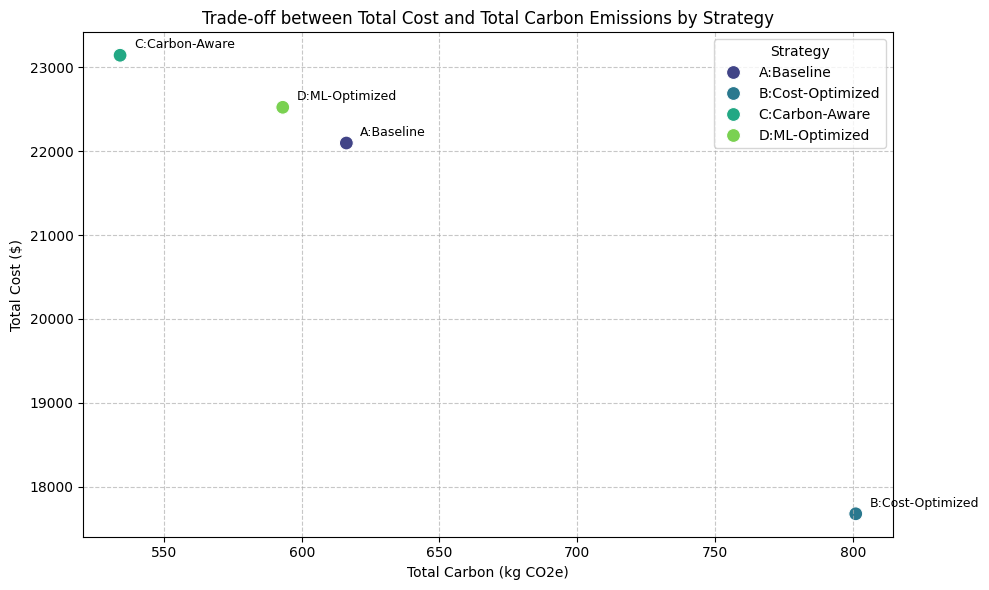

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(10, 6))
sns.scatterplot(x='Total Carbon(kg CO2e)', y='Total Cost($)', hue='Strategy', data=results_df, s=100, palette='viridis')

for i, row in results_df.iterrows():
    plt.text(row['Total Carbon(kg CO2e)'] + 5, row['Total Cost($)'] + 50, row['Strategy'],
             horizontalalignment='left', verticalalignment='bottom', fontsize=9)

plt.title('Trade-off between Total Cost and Total Carbon Emissions by Strategy')
plt.xlabel('Total Carbon (kg CO2e)')
plt.ylabel('Total Cost ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

From the table and the scatter plot, we can observe the following trade-offs:

*   **A: Baseline**: This strategy represents the standard operational cost and carbon footprint.
*   **B: Cost-Optimized**: This strategy significantly reduces cost but at the expense of higher carbon emissions, indicating a clear trade-off where financial savings lead to a dirtier grid.
*   **C: Carbon-Aware**: This strategy shows the lowest carbon emissions, but it comes with a slightly higher cost than the baseline. This suggests that optimizing for carbon involves some financial premium, likely due to shifting workloads to more expensive but greener times.
*   **D: ML-Optimized**: This strategy attempts to balance both cost and carbon. It shows a lower carbon footprint than the baseline and is also slightly more expensive than the cost-optimized strategy. It strikes a balance, offering better carbon efficiency than the baseline without the significant cost increase seen in the carbon-aware strategy.

In [17]:
print("\n Step 5:Executing TOPSIS Multi-Criteria Decsision Analysis..")
#Decision Matrix
X_matrix= results_df[["Total Cost($)","Total Carbon(kg CO2e)","Avg Latency (ms)","SLA Compliance(%)"]].values

#Weights(Corporate Strategy:Sustainable Focused)
weights=np.array([0.30,0.40,0.20,0.10])#Cost,Carbon,Latency
beneficial=[-1,-1,-1,1]#-1 for non-beneficial(lower is better),1 for beneficial(higher is better)

#Step 5.1:Normalize
norm_X = X_matrix/np.sqrt((X_matrix**2).sum(axis=0))
#Step 5.2:Weight
weight_X =norm_X *weights
#Step 5.3:Ideal and Anti-ideal
ideal=np.where(beneficial==1,weight_X.max(axis=0),weight_X.min(axis=0))
anti_ideal=np.where(beneficial==1,weight_X.min(axis=0),weight_X.max(axis=0))
#Step 5.4:Distances
dist_ideal=np.sqrt(((weight_X-ideal)**2).sum(axis=1))
dist_anti=np.sqrt(((weight_X-anti_ideal)**2).sum(axis=1))
#Step 5.5:Closeness Coefficient
closeness=dist_anti/(dist_ideal+dist_anti)
results_df["TOPSIS Score"]=closeness
results_df["Rank"]=results_df["TOPSIS Score"].rank(ascending=False).astype(int)

#Claculate Carbon Reduction vs Baseline
baseline_carbon=results_df.loc[results_df["Strategy"]=="A:Baseline","Total Carbon(kg CO2e)"].values[0]
results_df["Carbon Reduction(%)"]=((baseline_carbon-results_df["Total Carbon(kg CO2e)"])/baseline_carbon)*100

print("\n FINAL RESEARCH OUTPUT:Strategic Alignment Scorecard")
print(results_df[["Strategy","Rank","TOPSIS Score","Total Carbon(kg CO2e)","Carbon Reduction(%)","Total Cost($)"]].sort_values("Rank").to_string(index=False))
print("\nResearch simulation complete.")



 Step 5:Executing TOPSIS Multi-Criteria Decsision Analysis..

 FINAL RESEARCH OUTPUT:Strategic Alignment Scorecard
        Strategy  Rank  TOPSIS Score  Total Carbon(kg CO2e)  Carbon Reduction(%)  Total Cost($)
  D:ML-Optimized     1      0.658374             593.130946             3.746004   22523.087711
  C:Carbon-Aware     2      0.657594             534.083361            13.328317   23143.202675
      A:Baseline     3      0.650913             616.214362             0.000000   22097.187354
B:Cost-Optimized     4      0.285847             801.078671           -30.000000   17677.749883

Research simulation complete.


## Step 6: Sensitivity Analysis on Strategy Weights

We will now perform a sensitivity analysis by varying the weights assigned to each criterion (Cost, Carbon, Latency, SLA Compliance) in the TOPSIS model. This helps understand how the strategic priorities influence the ranking of the different cloud allocation strategies.

In [18]:
print("\nStep 6: Executing Sensitivity Analysis on Strategy Weights..")

# Define different weight scenarios
weight_scenarios = {
    "Sustainable Focus": np.array([0.30, 0.40, 0.20, 0.10]), # Original weights
    "Cost Focus": np.array([0.60, 0.10, 0.20, 0.10]),
    "Performance Focus": np.array([0.20, 0.10, 0.40, 0.30]),
    "Balanced Focus": np.array([0.25, 0.25, 0.25, 0.25])
}

# Prepare a DataFrame to store sensitivity analysis results
sensitivity_results = []

# Decision Matrix (X_matrix) and Beneficial/Non-Beneficial criteria are the same
# from the previous TOPSIS calculation
X_matrix = results_df[["Total Cost($)","Total Carbon(kg CO2e)","Avg Latency (ms)","SLA Compliance(%)"]].values
beneficial = [-1, -1, -1, 1] # -1 for non-beneficial (lower is better), 1 for beneficial (higher is better)

# Step 5.1: Normalize (this remains constant as it does not depend on weights)
norm_X = X_matrix / np.sqrt((X_matrix**2).sum(axis=0))

for scenario_name, weights in weight_scenarios.items():
    # Step 5.2: Weight the normalized matrix
    weight_X = norm_X * weights

    # Step 5.3: Determine Ideal and Anti-Ideal Solutions
    ideal = np.where(beneficial == 1, weight_X.max(axis=0), weight_X.min(axis=0))
    anti_ideal = np.where(beneficial == 1, weight_X.min(axis=0), weight_X.max(axis=0))

    # Step 5.4: Calculate Separation Distances
    dist_ideal = np.sqrt(((weight_X - ideal)**2).sum(axis=1))
    dist_anti = np.sqrt(((weight_X - anti_ideal)**2).sum(axis=1))

    # Step 5.5: Calculate Closeness Coefficient
    closeness = dist_anti / (dist_ideal + dist_anti)

    # Add results to a temporary DataFrame for this scenario
    scenario_df = pd.DataFrame({
        'Strategy': results_df['Strategy'],
        'TOPSIS Score': closeness,
        'Rank': pd.Series(closeness).rank(ascending=False).astype(int)
    })
    scenario_df['Scenario'] = scenario_name
    scenario_results = scenario_df.merge(results_df[['Strategy', 'Total Cost($)', 'Total Carbon(kg CO2e)', 'Carbon Reduction(%)']], on='Strategy')
    sensitivity_results.append(scenario_results)

# Combine all scenario results
final_sensitivity_df = pd.concat(sensitivity_results).sort_values(by=['Scenario', 'Rank'])

display(final_sensitivity_df.round(3))

print("\nSensitivity analysis complete.")



Step 6: Executing Sensitivity Analysis on Strategy Weights..


,Strategy,TOPSIS Score,Rank,Scenario,Total Cost($),Total Carbon(kg CO2e),Carbon Reduction(%)
0,A:Baseline,0.696,1,Balanced Focus,22097.187,616.214,0.000
3,D:ML-Optimized,0.665,2,Balanced Focus,22523.088,593.131,3.746
2,C:Carbon-Aware,0.579,3,Balanced Focus,23143.203,534.083,13.328
1,B:Cost-Optimized,0.289,4,Balanced Focus,17677.750,801.079,-30.000
1,B:Cost-Optimized,0.597,1,Cost Focus,17677.750,801.079,-30.000
0,A:Baseline,0.453,2,Cost Focus,22097.187,616.214,0.000
3,D:ML-Optimized,0.388,3,Cost Focus,22523.088,593.131,3.746
2,C:Carbon-Aware,0.282,4,Cost Focus,23143.203,534.083,13.328
0,A:Baseline,0.815,1,Performance Focus,22097.187,616.214,0.000
3,D:ML-Optimized,0.742,2,Performance Focus,22523.088,593.131,3.746



Sensitivity analysis complete.



Visualizing trade-offs across scenarios...


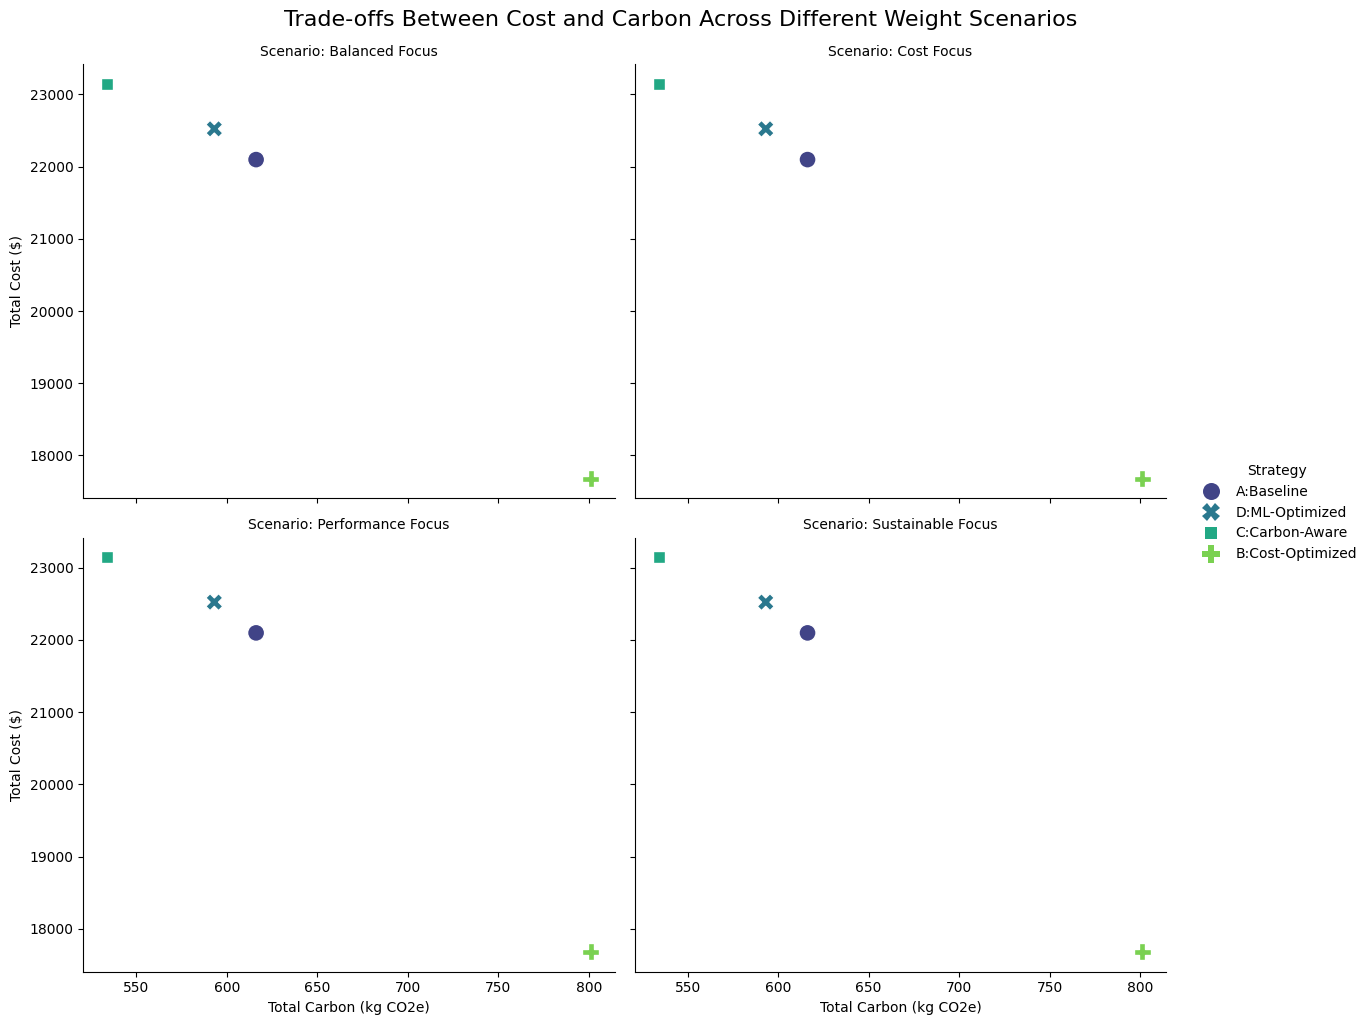


Visualization complete.


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nVisualizing trade-offs across scenarios...")

# Create a faceted scatter plot for each scenario
g = sns.relplot(
    data=final_sensitivity_df,
    x='Total Carbon(kg CO2e)',
    y='Total Cost($)',
    col='Scenario',
    hue='Strategy',
    style='Strategy',
    kind='scatter',
    height=5,
    aspect=1.2,
    s=150, # Marker size
    col_wrap=2, # Wrap plots after 2 columns
    palette='viridis'
)

g.set_axis_labels('Total Carbon (kg CO2e)', 'Total Cost ($)')
g.set_titles('Scenario: {col_name}')
g.tight_layout()
plt.suptitle('Trade-offs Between Cost and Carbon Across Different Weight Scenarios', y=1.02, fontsize=16)
plt.show()

print("\nVisualization complete.")
